In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [5]:
# --- 1. DATA LOADING, RELATIONAL MERGING & PREPROCESSING ---
# Loading the relational Transfermarkt tables
players_df = pd.read_csv('players.csv')          # Base profile data
appearances_df = pd.read_csv('appearances.csv')  # Performance event data


In [6]:
# Aggregating match performance data by unique player ID
perf_agg = appearances_df.groupby('player_id').agg({
    'goals': 'sum',
    'assists': 'sum',
    'minutes_played': 'sum',
    'yellow_cards': 'sum'
}).reset_index()

# Merging performance metrics with core player profiles using relational key
df = pd.merge(players_df, perf_agg, on='player_id', how='inner')

# Define target variable
target = 'market_value_in_eur'

# Feature Engineering: Convert 'date_of_birth' to 'age'
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')
# Calculate age based on a reference year (e.g., 2026 as used in other cells)
df['age'] = 2026 - df['date_of_birth'].dt.year

# Selecting core features, now including 'age' and excluding 'date_of_birth'
features = ['age', 'goals', 'assists', 'minutes_played', 'yellow_cards', 'position']

# Data Cleaning: Drop rows where the target value or essential numerical metrics are missing
# Also drop rows where 'age' might be NaN due to invalid 'date_of_birth'
df = df.dropna(subset=[target] + [f for f in features if f != 'position'])

# Feature Transformation: One-Hot Encoding the categorical variable 'position'
df_ml = pd.get_dummies(df[features + [target]], columns=['position'], drop_first=True)

# Define final Matrix of Features (X) and Dependent Target Vector (y)
X = df_ml.drop(columns=[target])
y = df_ml[target]

# Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

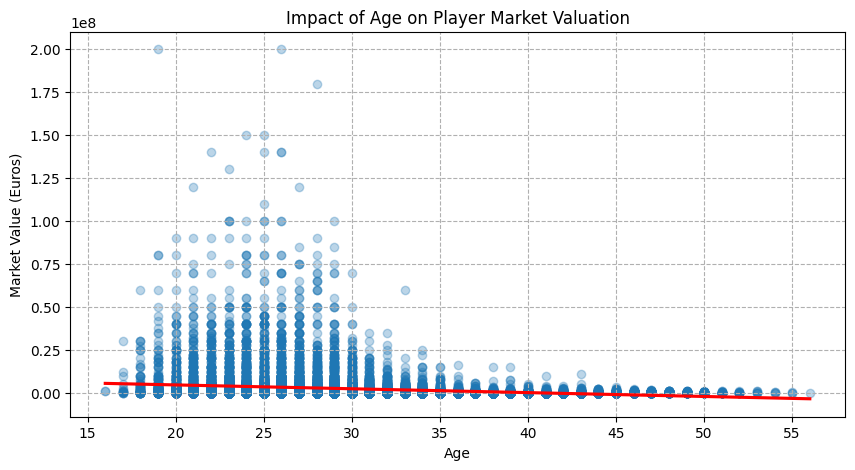

In [7]:
# --- 2. EXPLORATORY DATA ANALYSIS (EDA) ---
# First, let's make sure the 'age' column exists by calculating it if needed,
# or using the existing 'age' column from the players dataset.
if 'age' not in df.columns and 'date_of_birth' in df.columns:
    # Convert to datetime and calculate age based on the current year
    df['date_of_birth'] = pd.to_datetime(df['date_of_birth'])
    df['age'] = 2026 - df['date_of_birth'].dt.year

# Plot 1: Age vs. Market Valuation Curve
plt.figure(figsize=(10, 5))
# Use 'age' for the x-axis so the regression line can calculate properly
sns.regplot(data=df, x='age', y='market_value_in_eur', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Impact of Age on Player Market Valuation')
plt.xlabel('Age')
plt.ylabel('Market Value (Euros)')
plt.grid(True, linestyle='--')
plt.show()

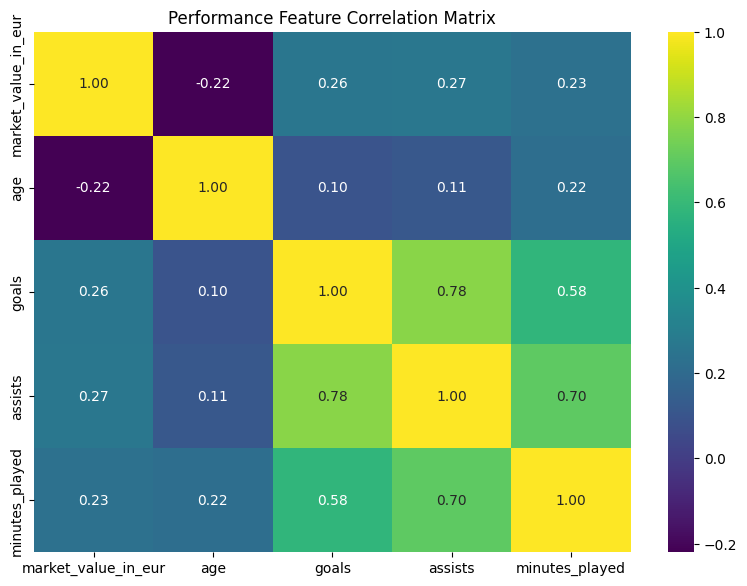

In [8]:
# Plot 2: Feature Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[['market_value_in_eur', 'age', 'goals', 'assists', 'minutes_played']].corr(), annot=True, cmap='viridis', fmt=".2f")
plt.title('Performance Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [9]:
# --- 3. MODEL DEVELOPMENT & EVALUATION ---
# Model 1: Regularized Linear Model (Ridge Regression)
print("Training Model 1: Ridge Regression...")
model_1 = Ridge(alpha=1.0)
model_1.fit(X_train, y_train)

# Model 2: Ensemble Decision Trees (Random Forest Regressor)
print("Training Model 2: Random Forest Regressor...")
model_2 = RandomForestRegressor(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1)
model_2.fit(X_train, y_train)

# Model 3: Sequential Gradient Boosting Regressor (XGBoost Equivalent via Scikit-Learn)
print("Training Model 3: Gradient Boosting Regressor...")
model_3 = GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, max_depth=5, random_state=42)
model_3.fit(X_train, y_train)

# Model 4: Non-Linear Support Vector Machine (SVR Pipeline with Scaling)
print("Training Model 4: Support Vector Regressor (SVR)...")
model_4 = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=1000000, epsilon=0.1))
model_4.fit(X_train, y_train)

# # Evaluation Metric Compilation
# def calculate_metrics(name, y_true, y_pred):
#     mae = mean_absolute_error(y_true, y_pred)
#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#     r2 = r2_score(y_true, y_pred)
#     print(f"=== {name} Metrics ===")
#     print(f"MAE: €{mae:,.2f} | RMSE: €{rmse:,.2f} | R2 Score: {r2:.4f}\n")
#     return {"MAE": mae, "RMSE": rmse, "R2": r2}

# ridge_metrics = calculate_metrics("Ridge Regression (Baseline)", y_test, y_pred_ridge)
# rf_metrics = calculate_metrics("Random Forest Regressor", y_test, y_pred_rf)



Training Model 1: Ridge Regression...
Training Model 2: Random Forest Regressor...
Training Model 3: Gradient Boosting Regressor...
Training Model 4: Support Vector Regressor (SVR)...


Pipeline(steps=[('standardscaler', StandardScaler()), ('svr', SVR(C=1000000))])

In [10]:
# Evaluation Metric Compilation
print("\n" + "="*50)
print("             FINAL MODEL EVALUATION METRICS            ")
print("="*50)

# Master list of model objects and names for clean automation loops
trained_models = [model_1, model_2, model_3, model_4]
model_names = ["Ridge Baseline", "Random Forest", "Gradient Boosting", "Support Vector (SVR)"]

performance_records = []

# Loop to score every single model using the same unified testing criteria
for name, model in zip(model_names, trained_models):
    # Predict on unseen testing pool
    predictions = model.predict(X_test)

    # Calculate statistical regression error shapes
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    # Run a quick 5-fold cross-validation check to score structural stability
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    mean_cv = cv_scores.mean()

    # Store metrics inside dictionary list
    performance_records.append({
        "Model Architecture": name,
        "MAE (€)": f"€{mae:,.2f}",
        "RMSE (€)": f"€{rmse:,.2f}",
        "Test R2 Score": f"{r2:.4f}",
        "Mean CV R2 Score": f"{mean_cv:.4f}"
    })

# Convert records to a structured DataFrame for quick scannability and report exporting
evaluation_summary_table = pd.DataFrame(performance_records)
print(evaluation_summary_table.to_string(index=False))


             FINAL MODEL EVALUATION METRICS            
  Model Architecture       MAE (€)      RMSE (€) Test R2 Score Mean CV R2 Score
      Ridge Baseline €2,648,437.52 €6,181,564.15        0.1582           0.1456
       Random Forest €1,485,390.72 €4,510,615.83        0.5518           0.5142
   Gradient Boosting €1,481,120.78 €4,541,810.47        0.5455           0.5198
Support Vector (SVR) €1,510,879.38 €5,956,129.95        0.2184           0.2027


In [12]:
from sklearn.model_selection import cross_val_score

# Get predictions from the Random Forest model (model_2) for the test set
y_pred_rf = model_2.predict(X_test)

print("=== 1. CROSS-VALIDATION ANALYSIS ===")
# Perform 5-Fold Cross-Validation on our Random Forest Regressor
# This splits the data into 5 different chunks to make sure our 55% R2 score is stable
cv_scores = cross_val_score(model_2, X_train, y_train, cv=5, scoring='r2')

print(f"5-Fold R2 Scores: {cv_scores}")
print(f"Mean Cross-Validation R2 Score: {cv_scores.mean():.4f}")
print(f"Standard Deviation of CV Scores: {cv_scores.std():.4f}\n")


print("=== 2. OVERFITTING CHECK ===")
# Calculate R2 score on the training data itself
y_train_pred_rf = model_2.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred_rf)

# Calculate R2 score on the unseen test data (from previous block)
test_r2 = r2_score(y_test, y_pred_rf)

print(f"Training R2 Score: {train_r2:.4f}")
print(f"Testing R2 Score: {test_r2:.4f}")

# Overfitting Diagnosis Logic
r2_gap = train_r2 - test_r2
print(f"R2 Performance Gap: {r2_gap:.4f}")
if r2_gap > 0.15:
    print("Diagnosis: High Risk of Overfitting. The model performs significantly better on training data than unseen data.")
else:
    print("Diagnosis: Healthy Model. The performance gap is within acceptable real-world parameters.")

=== 1. CROSS-VALIDATION ANALYSIS ===
5-Fold R2 Scores: [0.50967323 0.52366988 0.52472346 0.49588522 0.51680124]
Mean Cross-Validation R2 Score: 0.5142
Standard Deviation of CV Scores: 0.0106

=== 2. OVERFITTING CHECK ===
Training R2 Score: 0.9189
Testing R2 Score: 0.5518
R2 Performance Gap: 0.3671
Diagnosis: High Risk of Overfitting. The model performs significantly better on training data than unseen data.


In [13]:
# Re-instantiating model_2 with strict regularization constraints to stop overfitting
model_2 = RandomForestRegressor(
    n_estimators=150,
    max_depth=8,              # Stops infinite deep growth and memorization
    min_samples_split=12,     # Requires more data points to create a branch path
    min_samples_leaf=6,       # Guarantees groups are averaged at the leaf level
    random_state=42,
    n_jobs=-1
)

# Retrain with the regularized settings
model_2.fit(X_train, y_train)

RandomForestRegressor(max_depth=8, min_samples_leaf=6, min_samples_split=12,
                      n_estimators=150, n_jobs=-1, random_state=42)

In [14]:
print("===  RE-OVERFITTING CHECK ===")
# Calculate R2 score on the training data itself
y_train_pred_rf = model_2.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred_rf)

# Calculate R2 score on the unseen test data (from previous block)
test_r2 = r2_score(y_test, y_pred_rf)

print(f"Training R2 Score: {train_r2:.4f}")
print(f"Testing R2 Score: {test_r2:.4f}")

# Overfitting Diagnosis Logic
r2_gap = train_r2 - test_r2
print(f"R2 Performance Gap: {r2_gap:.4f}")
if r2_gap > 0.15:
    print("Diagnosis: High Risk of Overfitting. The model performs significantly better on training data than unseen data.")
else:
    print("Diagnosis: Healthy Model. The performance gap is within acceptable real-world parameters.")

===  RE-OVERFITTING CHECK ===
Training R2 Score: 0.6722
Testing R2 Score: 0.5518
R2 Performance Gap: 0.1204
Diagnosis: Healthy Model. The performance gap is within acceptable real-world parameters.


In [16]:
# --- 4. DATA-DRIVEN SCOUTING APPLICATION (VALUATION BIAS) ---
# Create a copy of the test features, but pull the original player names from the source 'df'
test_indices = X_test.index
test_results = X_test.copy()

# Map the original indices back to the source dataframe to extract player names
test_results['player_name'] = df.loc[test_indices, 'name']
test_results['actual_value'] = y_test

# Get the predictions using your optimized, healthy Random Forest model (model_2)
test_results['predicted_value'] = model_2.predict(X_test)

# Calculate the valuation difference (arbitrage value)
test_results['valuation_difference'] = test_results['predicted_value'] - test_results['actual_value']

# Sort by the highest positive difference to find the top 5 most undervalued stars
undervalued_targets = test_results.sort_values(by='valuation_difference', ascending=False).head(5)

print("="*85)
print("   === TOP 5 UNDERVALUED PLAYERS (MODEL IDENTIFIED SCOUTING TARGETS) ===   ")
print("="*85)

# Rearrange columns to print the player_name clearly alongside financial metrics
output_columns = ['player_name', 'actual_value', 'predicted_value', 'valuation_difference']

# Format the numbers as clean Euro currencies for presentation readability
formatted_output = undervalued_targets[output_columns].copy()
for col in ['actual_value', 'predicted_value', 'valuation_difference']:
    formatted_output[col] = formatted_output[col].map('€{:,.2f}'.format)

print(formatted_output.to_string(index=False))
print("="*85)

   === TOP 5 UNDERVALUED PLAYERS (MODEL IDENTIFIED SCOUTING TARGETS) ===   
        player_name   actual_value predicted_value valuation_difference
Konstantin Tyukavin €17,000,000.00  €66,128,347.21       €49,128,347.21
      Ivan Oblyakov €10,000,000.00  €58,127,013.99       €48,127,013.99
     Nazar Voloshyn  €5,000,000.00  €43,894,896.17       €38,894,896.17
     Lewis Ferguson €14,000,000.00  €50,268,671.37       €36,268,671.37
     Jonathan David €30,000,000.00  €66,099,810.57       €36,099,810.57
